In [6]:
# Практика 11. Закон великих чисел і ЦГТ
# Коць Артем, ІТ-42
# Варіант 9 — Суми

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(9)

lam = 0.24
true_mean = 1 / lam

print("Місто: Суми")
print("λ =", lam)
print("Теоретичне E[X] =", true_mean)

Місто: Суми
λ = 0.24
Теоретичне E[X] = 4.166666666666667


In [2]:
sample_sizes = [5, 50, 500, 20_000]

for n in sample_sizes:
    sample = rng.exponential(
        scale=1 / lam,
        size=n
    )
    
    sample_mean = sample.mean()
    difference = abs(sample_mean - true_mean)
    
    print(
        f"n = {n:>5} | "
        f"середнє = {sample_mean:.4f} | "
        f"абсолютна різниця = {difference:.4f}"
    )

n =     5 | середнє = 5.4375 | абсолютна різниця = 1.2708
n =    50 | середнє = 4.2621 | абсолютна різниця = 0.0955
n =   500 | середнє = 4.0861 | абсолютна різниця = 0.0806
n = 20000 | середнє = 4.1631 | абсолютна різниця = 0.0036


### Завдання 1. Перевірка закону великих чисел

Теоретичне середнє експоненційного розподілу для мого варіанта
становить:

E[X] = 1 / λ = 1 / 0.24 ≈ 4.1667 хв.

За результатами симуляції видно, що зі збільшенням розміру вибірки
вибіркове середнє x̄ загалом наближається до теоретичного середнього.
Абсолютна різниця між x̄ та E[X] при великих n стає меншою.

Це демонструє закон великих чисел: зі зростанням кількості
спостережень вибіркове середнє наближається до теоретичного
математичного сподівання генеральної сукупності.

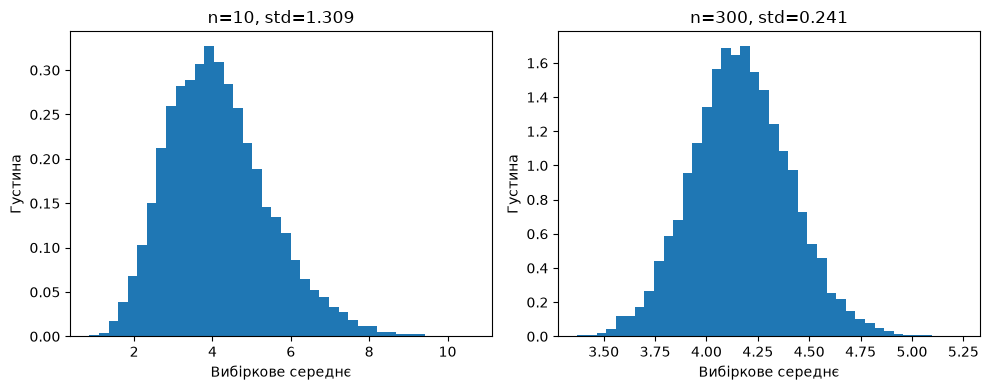

In [3]:
n_repeats = 10_000

means_n10 = rng.exponential(
    scale=1 / lam,
    size=(n_repeats, 10)
).mean(axis=1)

means_n300 = rng.exponential(
    scale=1 / lam,
    size=(n_repeats, 300)
).mean(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].hist(
    means_n10,
    bins=40,
    density=True
)
axes[0].set_title(
    f"n=10, std={means_n10.std():.3f}"
)
axes[0].set_xlabel("Вибіркове середнє")
axes[0].set_ylabel("Густина")

axes[1].hist(
    means_n300,
    bins=40,
    density=True
)
axes[1].set_title(
    f"n=300, std={means_n300.std():.3f}"
)
axes[1].set_xlabel("Вибіркове середнє")
axes[1].set_ylabel("Густина")

plt.tight_layout()
plt.show()

In [7]:
results = []

for n in [10, 30, 100, 300]:
    sample_means = rng.exponential(
        scale=1 / lam,
        size=(n_repeats, n)
    ).mean(axis=1)

    se_theoretical = (1 / lam) / np.sqrt(n)
    measured_std = sample_means.std()

    results.append({
        "n": n,
        "теоретична SE": se_theoretical,
        "виміряна std": measured_std
    })

se_table = pd.DataFrame(results)

se_table

,n,теоретична SE,виміряна std
0,10,1.317616,1.323051
1,30,0.760726,0.755102
2,100,0.416667,0.422448
3,300,0.240563,0.239366


In [8]:
se_25 = (1 / lam) / np.sqrt(25)
se_100 = (1 / lam) / np.sqrt(100)

print("SE для n=25:", se_25)
print("SE для n=100:", se_100)
print("Відношення SE(25) / SE(100):", se_25 / se_100)

SE для n=25: 0.8333333333333334
SE для n=100: 0.4166666666666667
Відношення SE(25) / SE(100): 2.0


### Завдання 4. Закон убуваючої віддачі

Для n = 25 стандартна похибка становить приблизно 0.8333,
а для n = 100 — приблизно 0.4167.

При збільшенні розміру вибірки у 4 рази стандартна похибка
зменшилася у 2 рази.

Це пояснюється формулою:

SE = σ / √n.

Оскільки n знаходиться під квадратним коренем, збільшення вибірки
у 4 рази дає лише двократне зменшення стандартної похибки.

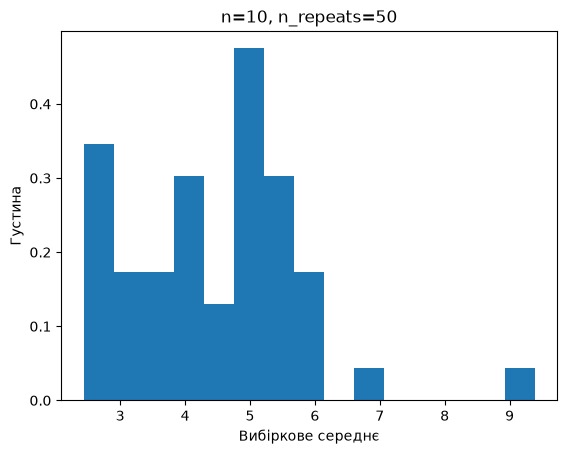

In [9]:
n_repeats_small = 50

means_n10_small = rng.exponential(
    scale=1 / lam,
    size=(n_repeats_small, 10)
).mean(axis=1)

plt.hist(
    means_n10_small,
    bins=15,
    density=True
)

plt.xlabel("Вибіркове середнє")
plt.ylabel("Густина")
plt.title("n=10, n_repeats=50")
plt.show()

### Завдання 5. Вплив n_repeats на якість симуляції

При n=10 та n_repeats=50 гістограма вибіркового розподілу
середнього виходить значно менш гладкою, ніж при 10 000 повторень.

Причина полягає в тому, що n_repeats визначає кількість точок,
з яких будується гістограма. Чим більше повторних вибірок, тим
стабільнішою та гладкішою є форма гістограми.

Розмір однієї вибірки n впливає на розкид і форму розподілу
вибіркового середнього, а n_repeats визначає кількість
повторень для побудови цього розподілу.

## Контрольні питання

### 1. Чим відрізняється закон великих чисел від центральної граничної теореми?

Закон великих чисел відповідає на питання, куди прямує вибіркове
середнє x̄ зі збільшенням розміру вибірки. Воно наближається до
теоретичного математичного сподівання E[X].

Центральна гранична теорема відповідає на питання, якої форми та
розкиду набуває розподіл вибіркового середнього. За достатньо
великого n цей розподіл наближається до нормального, а його
стандартне відхилення визначається стандартною похибкою σ/√n.

### 2. Чому вихідний розподіл часу очікування обрано сильно скошеним?

Експоненційний розподіл є сильно скошеним вправо, тому він добре
демонструє роботу центральної граничної теореми.

При малому n розподіл вибіркових середніх ще зберігає помітну
скошеність. При збільшенні n він стає дедалі більш дзвоноподібним
і наближається до нормального.

Якби вихідні дані одразу мали нормальний розподіл, перехід до
нормальної форми був би значно менш наочним.

### 3. Чому стандартна похибка зменшується пропорційно √n?

Стандартна похибка визначається формулою:

SE = σ / √n.

Тому при збільшенні n у 4 рази стандартна похибка зменшується
у 2 рази, а не у 4.

Щоб зменшити стандартну похибку вдвічі, потрібно збільшити
розмір вибірки у чотири рази. Наприклад, перехід від n=25
до n=100 дає зменшення SE з приблизно 0.8333 до 0.4167.